In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('./data_complete.csv')

In [4]:
ahu6 = df[df['ahu_id'] == 'AHU1']

(array([3.3900e+02, 1.4070e+03, 1.3650e+03, 3.9840e+03, 7.1320e+03,
        1.2140e+04, 1.2311e+04, 1.5744e+04, 1.8023e+04, 1.9238e+04,
        1.7519e+04, 1.6249e+04, 1.3319e+04, 1.0788e+04, 9.4350e+03,
        8.4390e+03, 7.2410e+03, 6.2980e+03, 5.2950e+03, 3.8760e+03,
        2.9070e+03, 2.1140e+03, 1.4710e+03, 9.1900e+02, 5.2400e+02,
        2.5800e+02, 1.0000e+02, 4.3000e+01, 1.2000e+01, 6.0000e+00]),
 array([ 153.        ,  184.16666667,  215.33333333,  246.5       ,
         277.66666667,  308.83333333,  340.        ,  371.16666667,
         402.33333333,  433.5       ,  464.66666667,  495.83333333,
         527.        ,  558.16666667,  589.33333333,  620.5       ,
         651.66666667,  682.83333333,  714.        ,  745.16666667,
         776.33333333,  807.5       ,  838.66666667,  869.83333333,
         901.        ,  932.16666667,  963.33333333,  994.5       ,
        1025.66666667, 1056.83333333, 1088.        ]),
 <BarContainer object of 30 artists>)

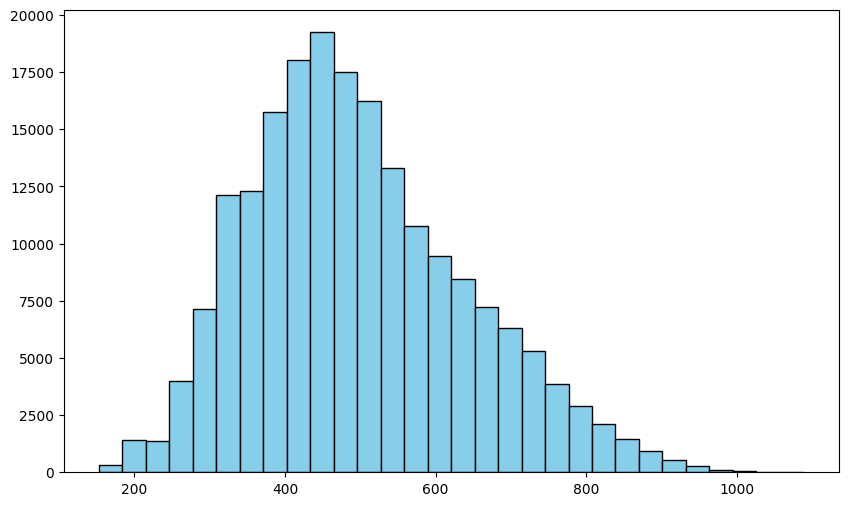

: 

In [ ]:
# distribution of current_co2
plt.figure(figsize=(10, 6))
plt.hist(df['current_co2'], bins=30, color='skyblue', edgecolor='black')


In [53]:
df['AHU_MODE'].value_counts()

AHU_MODE
1.0    140923
4.0     45407
2.0     12034
Name: count, dtype: int64

In [54]:
df.columns

Index(['timestamp', 'floor_id', 'hvac_zone', 'current_co2',
       'current_temperature', 'current_humidity', 'floor', 'corner', 'ahu_id',
       'FCU_1', 'FCU_2', 'FCU_3', 'FCU_4', 'FCU_5', 'FCU_6', 'FCU_7', 'FCU_8',
       'FCU_9', 'FCU_10', 'FCU_11', 'AHU_MDM', 'AHU_MDT', 'AHU_MODE',
       'AHU_OBDM', 'AHU_RDT', 'AHU_RUN', 'AHU_SDT', 'AHU_TMSET', 'CHU_SS',
       'CHU_TMSET', 'temperature_out', 'humidity_out', 'solar_radiation'],
      dtype='object')

In [55]:
# FCUs modification, if active 1, otherwise if inactive or nan set to zero
ahu6[[f'FCU_{i}'for i in range(1,12)]] = ahu6[[f'FCU_{i}'for i in range(1,12)]].applymap(lambda it: 1 if it=='active' else 0)
ahu6['AHU_OBDM'].fillna(0,inplace=True)
ahu6['AHU_RUN'] = ahu6['AHU_RUN'].apply(lambda it: 1 if it=='active' else 0)
ahu6['CHU_SS'] = ahu6['CHU_SS'].apply(lambda it: 1 if it=='active' else 0)

C:\Users\COF1SGP\AppData\Local\Temp\ipykernel_15532\154155822.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ahu6[[f'FCU_{i}'for i in range(1,12)]] = ahu6[[f'FCU_{i}'for i in range(1,12)]].applymap(lambda it: 1 if it=='active' else 0)
C:\Users\COF1SGP\AppData\Local\Temp\ipykernel_15532\154155822.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ahu6['AHU_OBDM'].fillna(0,inplace=True)
C:\Users\COF1SGP\AppData\Local\Temp\ipykernel_15532\154155822.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[

C:\Users\COF1SGP\AppData\Local\Temp\ipykernel_15532\154155822.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ahu6['CHU_SS'] = ahu6['CHU_SS'].apply(lambda it: 1 if it=='active' else 0)


In [56]:
ahu6.drop(columns=['floor_id','hvac_zone','floor', 'corner','ahu_id'],inplace=True)

C:\Users\COF1SGP\AppData\Local\Temp\ipykernel_15532\2253785512.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ahu6.drop(columns=['floor_id','hvac_zone','floor', 'corner','ahu_id'],inplace=True)


In [57]:
ahu = ahu6.groupby('timestamp').mean().reset_index()

In [58]:
ahu['temp_ratio'] = ahu['AHU_SDT'] / ahu['AHU_RDT']
ahu['delta_RDT'] = ahu['AHU_RDT'].diff().abs()
ahu['delta_SDT'] = ahu['AHU_SDT'].diff().abs()
ahu['inertia'] = (ahu['delta_SDT'] - ahu['delta_RDT']).abs()

# get weekday, decide if it's weekend or not
ahu['timestamp'] = pd.to_datetime(ahu['timestamp'])
ahu['weekday'] = ahu['timestamp'].dt.weekday
ahu['is_weekend'] = ahu['weekday'].apply(lambda x: 1 if x >= 5 else 0)

# get hour
ahu['hour'] = ahu['timestamp'].dt.hour
ahu['hour_sin'] = -np.cos(2 * np.pi * ahu['hour'] / 24)

# decide if it's working hours or not
ahu['is_working_hour'] = ahu['hour'].apply(lambda x: 1 if 8 <= x <= 18 else 0)

ahu['month'] = ahu['timestamp'].dt.month
ahu['month_sin'] = np.sin(2 * np.pi * ahu['month'] / 12)

# get the running mean of the outdoor temperature for the last 7 days
ahu['t_out_RM7'] = ahu['temperature_out'].rolling(window=7*24*4, min_periods=1).mean()


(array([147.,  98.,  50.,  63., 170., 181.,  90., 167., 178.,  99., 262.,
        197.,  96.,  94., 116.,  92.,  81.,  45.,  42.,  90., 179., 230.,
         97.,  99.,  93., 215.,  42., 189., 192., 257., 318., 552., 254.,
         61., 120.,  44., 130., 235., 276., 279., 369.,  89.,  75., 107.,
        416., 267., 106., 177., 178., 176.]),
 array([10.97591766, 11.33903348, 11.70214931, 12.06526513, 12.42838095,
        12.79149678, 13.1546126 , 13.51772842, 13.88084425, 14.24396007,
        14.60707589, 14.97019172, 15.33330754, 15.69642336, 16.05953919,
        16.42265501, 16.78577083, 17.14888666, 17.51200248, 17.8751183 ,
        18.23823413, 18.60134995, 18.96446577, 19.3275816 , 19.69069742,
        20.05381324, 20.41692907, 20.78004489, 21.14316071, 21.50627654,
        21.86939236, 22.23250818, 22.59562401, 22.95873983, 23.32185565,
        23.68497148, 24.0480873 , 24.41120313, 24.77431895, 25.13743477,
        25.5005506 , 25.86366642, 26.22678224, 26.58989807, 26.95301389,
 

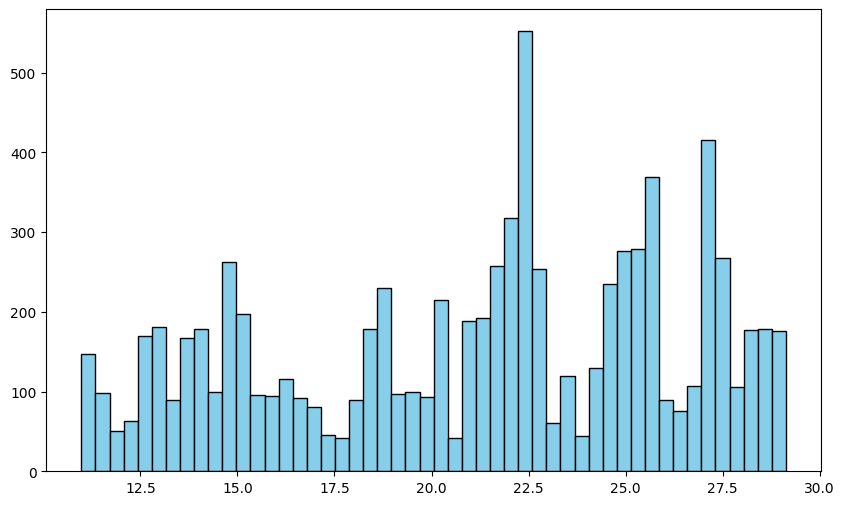

In [59]:
# plot t_out_RM7 dsitribution
plt.figure(figsize=(10,6))
plt.hist(ahu['t_out_RM7'], bins=50, color='skyblue', edgecolor='black')

In [60]:
# rewards
def compute_reward(row):
    comfort_penalty = 0
    energy_penalty = 0
    co2_penalty = 0

    # Comfort penalty based on temperature deviation from setpoint
    temp_deviation = (row['current_temperature'] - row['AHU_TMSET'])**2
    comfort_penalty += temp_deviation * 50  # weight for comfort

    # Air quality penalty
    co2_penalty = max(0, row['current_co2'] - 800) * 1  # weight for CO2
    
    # Reference setpoint from adaptive method EN 16798
    ref_setpoint = 18.3 + 0.33 * row['temperature_out']
    
    # Energy penalty based on OBDM and FCU usage
    capacity = (row['AHU_TMSET'] - ref_setpoint)**2
    energy_penalty += capacity * 25  # weight for OBDM
   

    total_penalty = comfort_penalty + energy_penalty + co2_penalty
    reward = -total_penalty/1000  # negative penalty as reward

    return reward

In [ ]:
# Setting actions
ahu['AHU_TMSET'] = (ahu['AHU_TMSET'].round()).fillna(method='ffill')
ahu['SET_ACT'] = ahu['AHU_TMSET'].copy() 

# AHU_OBDM needs to be rounded to have either of 5 values, pairing with 0%, 25% ... 100%
ahu['AHU_OBDM'] = (ahu['AHU_OBDM'] / 25).round() * 25
# Get the change in OBDM, positive or negative or none
ahu['OBDM_DIFF'] = ahu['AHU_OBDM'].diff().fillna(0)
ahu['OBDM_ACT'] = ahu['OBDM_DIFF'].apply(lambda it: 1 if it>0 else (-1 if it<0 else 0))


# If mode is 4 then set to 1, else 0
ahu['MODE_ACT'] = ahu['AHU_MODE'].apply(lambda it: 1 if it==4 else 0)

# for all FCU, set 1 or 0 by majority vite, single value in output
fcu_cols = [f'FCU_{i}'for i in range(1,12)]
ahu['FCU_ACT'] = ahu[fcu_cols].sum(axis=1)
ahu['FCU_ACT'] = ahu['FCU_ACT'].apply(lambda x: 1 if x >= 6 else 0)


(array([30808.,     0.,     0.,     0.,     0.,     0.,     0.,  5727.,
            0.,     0.,     0.,     0.,     0.,     0.,     0.,  3780.,
            0.,     0.,     0.,     0.,     0.,     0.,  3346.,     0.,
            0.,     0.,     0.,     0.,     0., 14095.]),
 array([  0.        ,   3.33333333,   6.66666667,  10.        ,
         13.33333333,  16.66666667,  20.        ,  23.33333333,
         26.66666667,  30.        ,  33.33333333,  36.66666667,
         40.        ,  43.33333333,  46.66666667,  50.        ,
         53.33333333,  56.66666667,  60.        ,  63.33333333,
         66.66666667,  70.        ,  73.33333333,  76.66666667,
         80.        ,  83.33333333,  86.66666667,  90.        ,
         93.33333333,  96.66666667, 100.        ]),
 <BarContainer object of 30 artists>)

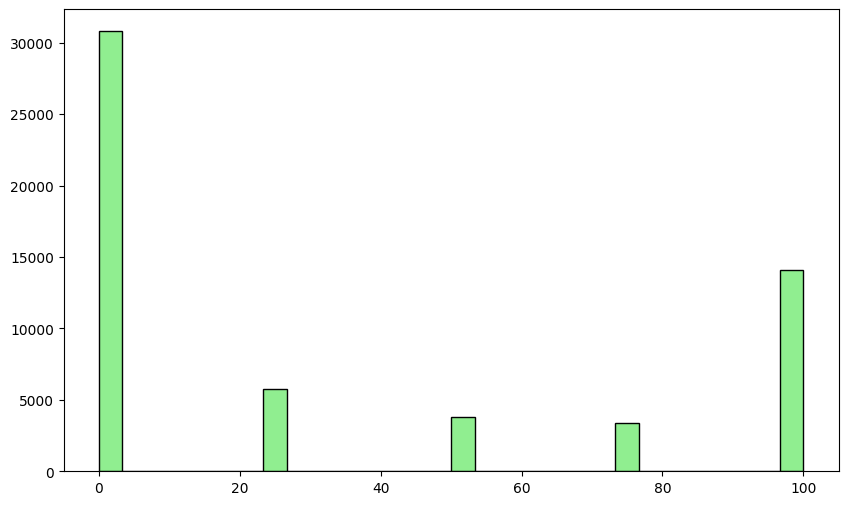

In [69]:
# plot a distribution of the changes is AHU_TMSET
obdm = (df['AHU_OBDM'] / 25).round() * 25

plt.figure(figsize=(10,6))
plt.hist(obdm.dropna(), bins=30, color='lightgreen', edgecolor='black')

<Axes: xlabel='FCU_ACT'>

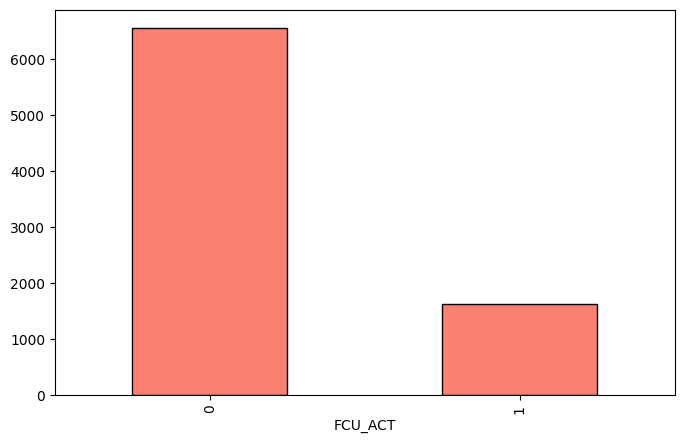

In [67]:
# count FCU_ACT by values, how many entries for each value
plt.figure(figsize=(8,5))
ahu['FCU_ACT'].value_counts().plot(kind='bar', color='salmon', edgecolor='black')

In [29]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

current_temp_scaler = StandardScaler()
ahu['current_temperature_t'] = current_temp_scaler.fit_transform(np.log(ahu[['current_temperature']]))

current_co2_scaler = StandardScaler()
ahu['current_co2_t'] = current_co2_scaler.fit_transform(np.log(ahu[['current_co2']]))

ahu['current_humidity_t'] = (ahu[['current_humidity']]**3)/1000000

mdt_scaler = StandardScaler()
ahu['AHU_MDT_t'] = mdt_scaler.fit_transform(ahu[['AHU_MDT']]**2)

rdt_scaler = StandardScaler()
ahu['AHU_RDT_t'] = rdt_scaler.fit_transform(np.log(ahu[['AHU_RDT']]))

sdt_scaler = StandardScaler()
ahu['AHU_SDT_t'] = sdt_scaler.fit_transform(ahu[['AHU_SDT']])

out_temp_scaler = StandardScaler()
ahu['temperature_out_t'] = out_temp_scaler.fit_transform((ahu[['temperature_out']]**1.5))

inertia_scaler = StandardScaler()
ahu['inertia_t'] = inertia_scaler.fit_transform((ahu[['inertia']]**(1/6)).fillna(0))

ratio_scaler = StandardScaler()
ahu['temp_ratio_t'] = ratio_scaler.fit_transform((ahu[['temp_ratio']]**3).fillna(0))

tset_scaler = StandardScaler()
ahu['temp_request'] = tset_scaler.fit_transform(ahu[['AHU_TMSET']].fillna(0))

In [30]:
(ahu['current_temperature_t'].skew(),
ahu['current_co2_t'].skew(),
ahu['current_humidity_t'].skew(),
ahu['AHU_MDT_t'].skew(),
ahu['AHU_RDT_t'].skew(),
ahu['AHU_SDT_t'].skew(),
ahu['temperature_out_t'].skew(),
ahu['inertia_t'].skew(),
ahu['temp_ratio_t'].skew(),
ahu['temp_request'].skew()
)

(-0.3071590368131788,
 0.6359337121278813,
 -0.3924604969919257,
 -0.5843945987928627,
 -0.6818515836587006,
 -0.35368736056712485,
 -0.0178187821043539,
 -0.00016401916866289884,
 1.4623503727807945,
 -1.0151802296526928)

In [31]:
observation = ahu[['temp_request','current_temperature_t','current_co2_t','current_humidity_t','AHU_MDT_t','AHU_RDT_t','AHU_SDT_t',
                   'temperature_out_t','inertia_t','temp_ratio_t','month_sin','hour_sin','is_weekend','is_working_hour']]

In [32]:
# create a new action column that contains a tuple of each of teh 4 actions per row
ahu['ACTION'] = list(zip(ahu['AHU_TMSET'], ahu['AHU_OBDM'], ahu['MODE_ACT'], ahu['FCU_ACT']))
action_mapping = {action: idx for idx, action in enumerate(ahu['ACTION'].unique())}
ahu['ACTION_CODE'] = ahu['ACTION'].map(action_mapping)


In [33]:
# np.array from the observation dataframe
observations = observation.fillna(method='bfill').to_numpy()

# np.array from the actions
actions = ahu['ACTION_CODE'].to_numpy()

In [34]:
len(observations)

8180

In [35]:
import gym
from gym import spaces

observation_space_def = spaces.Box(low=-np.inf, high=np.inf, shape=(14,), dtype=np.float32)
action_space_def = spaces.Discrete(52)


In [36]:
ahu['reward'] = ahu.apply(compute_reward, axis=1).fillna(method='bfill')

# set terminals, each day is an episode
ahu['date'] = ahu['timestamp'].dt.date
ahu['terminal'] = ahu['date'] != ahu['date'].shift(-1)
ahu['terminal'] = ahu['terminal'].astype(int)
ahu.drop(columns=['date'],inplace=True)


(array([ 23.,  65., 139., 176., 234., 301., 422., 491., 653., 662., 515.,
        693., 648., 556., 424., 384., 380., 294., 226., 191., 118., 122.,
         97.,  87.,  75.,  42.,  47.,  29.,  26.,  17.,  14.,  14.,   2.,
          2.,   4.,   0.,   3.,   1.,   0.,   0.,   0.,   1.,   0.,   0.,
          0.,   0.,   0.,   1.,   0.,   1.]),
 array([-8.61820223, -8.32289044, -8.02757864, -7.73226684, -7.43695504,
        -7.14164325, -6.84633145, -6.55101965, -6.25570786, -5.96039606,
        -5.66508426, -5.36977246, -5.07446067, -4.77914887, -4.48383707,
        -4.18852527, -3.89321348, -3.59790168, -3.30258988, -3.00727809,
        -2.71196629, -2.41665449, -2.12134269, -1.8260309 , -1.5307191 ,
        -1.2354073 , -0.9400955 , -0.64478371, -0.34947191, -0.05416011,
         0.24115168,  0.53646348,  0.83177528,  1.12708708,  1.42239887,
         1.71771067,  2.01302247,  2.30833427,  2.60364606,  2.89895786,
         3.19426966,  3.48958145,  3.78489325,  4.08020505,  4.37551685,
 

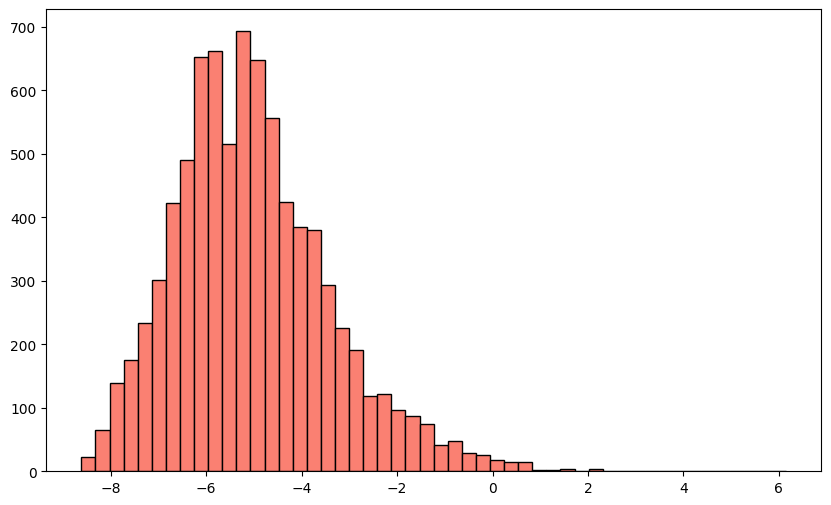

In [39]:
# plot rewards distribution
plt.figure(figsize=(10,6))
plt.hist(-np.log(-ahu['reward']), bins=50, color='salmon', edgecolor='black')

In [ ]:
# normalize reward
reward_scaler = StandardScaler()
reward_t = reward_scaler.fit_transform(ahu['reward'].to_numpy().reshape(-1, 1)).flatten()

In [40]:
from d3rlpy.dataset import MDPDataset
dataset = MDPDataset(observations, actions, ahu['reward'].to_numpy(), terminals=ahu['terminal'].to_numpy())

2025-11-28 23:32.13 [info     ] Signatures have been automatically determined. action_signature=Signature(dtype=[dtype('int64')], shape=[(1,)]) observation_signature=Signature(dtype=[dtype('float64')], shape=[(14,)]) reward_signature=Signature(dtype=[dtype('float64')], shape=[(1,)])
2025-11-28 23:32.13 [info     ] Action-space has been automatically determined. action_space=<ActionSpace.DISCRETE: 2>
2025-11-28 23:32.13 [info     ] Action size has been automatically determined. action_size=18


In [29]:
# use d3rlpy to train
from d3rlpy.algos import DiscreteCQLConfig
cql = DiscreteCQLConfig().create()

In [30]:
cql.fit(dataset, n_steps=10000)

2025-11-24 17:21.38 [info     ] dataset info                   dataset_info=DatasetInfo(observation_signature=Signature(dtype=[dtype('float64')], shape=[(14,)]), action_signature=Signature(dtype=[dtype('int64')], shape=[(1,)]), reward_signature=Signature(dtype=[dtype('float64')], shape=[(1,)]), action_space=<ActionSpace.DISCRETE: 2>, action_size=52)
2025-11-24 17:21.38 [debug    ] Building models...            
2025-11-24 17:21.39 [debug    ] Models have been built.       
2025-11-24 17:21.39 [info     ] Directory is created at d3rlpy_logs\DiscreteCQL_20251124172139
2025-11-24 17:21.39 [info     ] Parameters                     params={'observation_shape': [14], 'action_size': 52, 'config': {'type': 'discrete_cql', 'params': {'batch_size': 32, 'gamma': 0.99, 'observation_scaler': {'type': 'none', 'params': {}}, 'action_scaler': {'type': 'none', 'params': {}}, 'reward_scaler': {'type': 'none', 'params': {}}, 'compile_graph': False, 'learning_rate': 6.25e-05, 'optim_factory': {'type': 'a

Epoch 1/1:   0%|          | 0/10000 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
set(cql.predict(observations))

{0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 15, 17}

In [378]:
from d3rlpy.algos import DiscreteSACConfig
sac = DiscreteSACConfig().create()

2025-11-24 17:07.44 [info     ] dataset info                   dataset_info=DatasetInfo(observation_signature=Signature(dtype=[dtype('float64')], shape=[(14,)]), action_signature=Signature(dtype=[dtype('int64')], shape=[(1,)]), reward_signature=Signature(dtype=[dtype('float64')], shape=[(1,)]), action_space=<ActionSpace.DISCRETE: 2>, action_size=18)
2025-11-24 17:07.44 [debug    ] Building models...            
2025-11-24 17:07.44 [debug    ] Models have been built.       
2025-11-24 17:07.44 [info     ] Directory is created at d3rlpy_logs\DiscreteSAC_20251124170744
2025-11-24 17:07.44 [info     ] Parameters                     params={'observation_shape': [14], 'action_size': 18, 'config': {'type': 'discrete_sac', 'params': {'batch_size': 64, 'gamma': 0.99, 'observation_scaler': {'type': 'none', 'params': {}}, 'action_scaler': {'type': 'none', 'params': {}}, 'reward_scaler': {'type': 'none', 'params': {}}, 'compile_graph': False, 'actor_learning_rate': 0.0003, 'critic_learning_rate': 

Epoch 1/1:   0%|          | 0/10000 [00:00<?, ?it/s]

2025-11-24 17:10.21 [info     ] DiscreteSAC_20251124170744: epoch=1 step=10000 epoch=1 metrics={'time_sample_batch': 0.0009702041625976563, 'time_algorithm_update': 0.014603608107566833, 'critic_loss': 0.6072446797488723, 'actor_loss': -35.990626374959945, 'time_step': 0.015687687063217163} step=10000
2025-11-24 17:10.21 [info     ] Model parameters are saved to d3rlpy_logs\DiscreteSAC_20251124170744\model_10000.d3


(array([5002.,    0.,    0.,    0.,    0., 1702.,    0.,    0.,    0.,
        9838.]),
 array([ 4. ,  5.2,  6.4,  7.6,  8.8, 10. , 11.2, 12.4, 13.6, 14.8, 16. ]),
 <BarContainer object of 10 artists>)

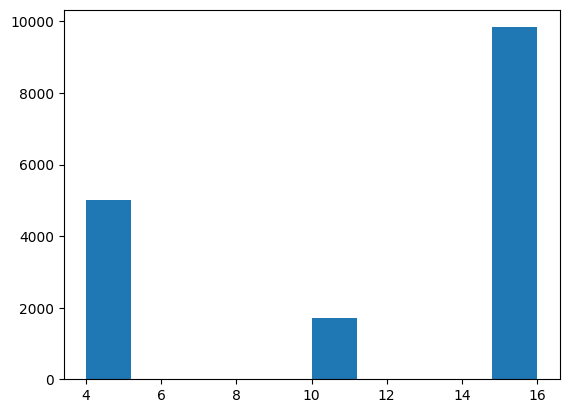

In [ ]:
sac.fit(dataset, n_steps=200000)
plt.hist(sac.predict(observations))

In [400]:
# create sample tests to check sanity of the controller
columns = ['current_temperature_t','current_co2_t','current_humidity_t','AHU_MDT_t','AHU_RDT_t','AHU_SDT_t',
                   'temperature_out_t','inertia_t','temp_ratio_t','month_sin','hour_sin','is_weekend','is_working_hour']

requested_temp = tset_scaler.transform([[23]])
current_temp = current_temp_scaler.transform(np.log([[26]]))
current_co2 = current_co2_scaler.transform(np.log([[1800]]))
current_humidity = [[80**3/1000000]]
mdt = mdt_scaler.transform([[25**2]])
rdt = rdt_scaler.transform(np.log([[27]]))
sdt = sdt_scaler.transform([[22]])
out_temp = out_temp_scaler.transform([[24**1.5]])
inertia = inertia_scaler.transform([[(0)**(1/6)]])
ratio = ratio_scaler.transform([[(22/24)**3]])
month_sin = np.sin(2 * np.pi * 8 / 12)
hour_sin = -np.cos(2 * np.pi * 10 / 24)
is_weekend = 0
is_working_hour = 1

test_sample = np.array([requested_temp[0][0],current_temp[0][0], current_co2[0][0], current_humidity[0][0], mdt[0][0], rdt[0][0], sdt[0][0],
                        out_temp[0][0], inertia[0][0], ratio[0][0], month_sin, hour_sin, is_weekend, is_working_hour]).reshape(1, -1)

cql_action = cql.predict(test_sample)
sac_action = sac.predict(test_sample)
print("CQL recommended action:", list(action_mapping.keys())[list(action_mapping.values()).index(cql_action[0])])
print("SAC recommended action:", list(action_mapping.keys())[list(action_mapping.values()).index(sac_action[0])])


c:\Users\COF1SGP\.conda\envs\eplus_rl\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\COF1SGP\.conda\envs\eplus_rl\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\COF1SGP\.conda\envs\eplus_rl\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\COF1SGP\.conda\envs\eplus_rl\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\COF1SGP\.conda\envs\eplus_rl\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\COF1SGP\.conda\envs\eplus_

CQL recommended action: (24.0, 0.0, 0, 0)
SAC recommended action: (24.0, 0.0, 1, 1)
